In [1]:
!pip install kaggle


In [ ]:
!pip install torch torchvision pillow kaggle


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from tqdm import tqdm
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch.nn.functional as F
from PIL import Image
import os
import cv2
from google.colab import files
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
os.environ['KAGGLE_USERNAME'] = "charlesigwe"
os.environ['KAGGLE_KEY'] = "KGAT_af5b702084c18a11e66e02c39a818ff7"


In [3]:

!kaggle datasets download -d cookiemonsteryum/reds-video-superresolution-toy-dataset -p /content/data
!unzip -q /content/data/reds-video-superresolution-toy-dataset.zip -d /content/data


Dataset URL: https://www.kaggle.com/datasets/cookiemonsteryum/reds-video-superresolution-toy-dataset
License(s): CC0-1.0
 92% 744M/811M [00:04<00:01, 39.5MB/s]
100% 811M/811M [00:04<00:00, 199MB/s] 



Explore the dataset structure by listing its contents, including subdirectories within 'hr' and sample files from the first HR sequence.


In [4]:

data_path = '/content/data'

print(f"Contents of {data_path}:")
print(os.listdir(data_path))

hr_path = os.path.join(data_path, 'hr')

if os.path.exists(hr_path) and os.path.isdir(hr_path):
    print(f"\nContents of {hr_path} (first 5 subdirectories):")
    hr_subdirs = sorted([d for d in os.listdir(hr_path) if os.path.isdir(os.path.join(hr_path, d))])
    for i, subdir in enumerate(hr_subdirs[:5]):
        print(f"  {subdir}")

    if hr_subdirs:
        first_hr_sequence_path = os.path.join(hr_path, hr_subdirs[0])
        print(f"\nSample .png files from the first HR sequence ({first_hr_sequence_path}, first 5 files):")
        png_files = sorted([f for f in os.listdir(first_hr_sequence_path) if f.endswith('.png')])
        for i, png_file in enumerate(png_files[:5]):
            print(f"  {png_file}")
    else:
        print("No subdirectories found in 'hr' path.")
else:
    print(f"\n{hr_path} does not exist or is not a directory.")


Contents of /content/data:
['hr', 'lr', 'reds-video-superresolution-toy-dataset.zip']

Contents of /content/data/hr (first 5 subdirectories):
  000
  001
  002
  003
  004

Sample .png files from the first HR sequence (/content/data/hr/000, first 5 files):
  00000000.png
  00000001.png
  00000002.png
  00000003.png
  00000004.png


noise and blur and dataset

### `REDDenoiseDataset`
 It takes clean, high-resolution (HR) images and dynamically applies noise and blur to create input-output pairs for training.

Gathers all `.png` image paths from specified HR subdirectories. It sets up image resizing and transformation to tensors. Crucially, it stores parameters for `noise_std` (standard deviation of Gaussian noise) and `blur_sigma` (strength of average pooling blur).
     **Adds Gaussian Noise**: Generates random numbers from a Gaussian distribution, scaled by `noise_std`, and adds them to the `clean` image to create `noisy` input. Applies Average Pooling Blur**: If `blur_sigma` is greater than 0, it applies a 2D average pooling operation to the `noisy` image.
  

In [6]:


class REDDenoiseDataset(Dataset):
    def __init__(self, hr_root, hr_subdirs, image_size=128,
                 noise_std=10.0, blur_sigma=1.0):
        self.paths = []
        for subdir in hr_subdirs:
            seq_dir = os.path.join(hr_root, subdir)
            if not os.path.isdir(seq_dir):
                continue
            for f in sorted(os.listdir(seq_dir)):
                if f.endswith(".png"):
                    self.paths.append(os.path.join(seq_dir, f))

        if len(self.paths) == 0:
            raise ValueError("No png frames found")

        self.resize = transforms.Resize((image_size, image_size))
        self.to_tensor = transforms.ToTensor()
        self.noise_std = noise_std
        self.blur_sigma = blur_sigma

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.resize(img)
        clean = self.to_tensor(img)  # in range 0 to 1

        sigma = self.noise_std / 255.0
        noise = torch.randn_like(clean) * sigma
        noisy = clean + noise

        if self.blur_sigma > 0.0:
            kernel_size = max(3, int(round(self.blur_sigma * 2)) * 2 + 1)
            pad = kernel_size // 2
            noisy_batch = noisy.unsqueeze(0)
            noisy_padded = F.pad(
                noisy_batch,
                (pad, pad, pad, pad),
                mode="reflect",
            )
            noisy_blur = F.avg_pool2d(
                noisy_padded,
                kernel_size=kernel_size,
                stride=1,
            )
            noisy = noisy_blur.squeeze(0)

        noisy = torch.clamp(noisy, 0.0, 1.0)
        return noisy, clean


UNet model

### U-Net Model
This code defines a U-Net architecture, commonly used for image-to-image tasks like denoising. It consists of:

DoubleConv: A basic building block comprising two convolutional layers, batch normalization, and ReLU activation.
UNet: The main model featuring an encoder (downsampling path), a bottleneck, and a decoder (upsampling path) with skip connections. This structure allows the model to capture context and reconstruct fine details, effectively transforming a degraded image into a cleaner version.

In [13]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=3, base_channels=64):
        super().__init__()
        self.down1 = DoubleConv(n_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 2, 2)
        self.conv3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 2, 2)
        self.conv2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, 2, 2)
        self.conv1 = DoubleConv(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, n_classes, 1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        bn = self.bottleneck(p3)

        u3 = self.up3(bn)
        x3 = self.conv3(torch.cat([u3, d3], dim=1))

        u2 = self.up2(x3)
        x2 = self.conv2(torch.cat([u2, d2], dim=1))

        u1 = self.up1(x2)
        x1 = self.conv1(torch.cat([u1, d1], dim=1))

        out = self.out_conv(x1)
        return out


hyperparameter combinations

### Hyperparameter Combinations
This cell defines a list of unique set of hyperparameters for training the U-Net model. These combinations are used for tuning and finding the optimal configuration.


In [14]:
hyperparameter_combinations = [
    {
        "learning_rate": 1e-3,
        "batch_size": 16,
        "num_epochs": 6,
        "noise_std": 8.0,
        "blur_sigma": 1.0,
        "base_channels": 64,
    },
    {
        "learning_rate": 5e-4,
        "batch_size": 16,
        "num_epochs": 6,
        "noise_std": 12.0,
        "blur_sigma": 1.3,
        "base_channels": 96,
    },
    {
        "learning_rate": 3e-4,
        "batch_size": 8,
        "num_epochs": 8,
        "noise_std": 15.0,
        "blur_sigma": 1.6,
        "base_channels": 128,
    },
]

print("Total combinations:", len(hyperparameter_combinations))
for i, c in enumerate(hyperparameter_combinations, 1):
    print("Combo", i, c)


Total combinations: 3
Combo 1 {'learning_rate': 0.001, 'batch_size': 16, 'num_epochs': 6, 'noise_std': 8.0, 'blur_sigma': 1.0, 'base_channels': 64}
Combo 2 {'learning_rate': 0.0005, 'batch_size': 16, 'num_epochs': 6, 'noise_std': 12.0, 'blur_sigma': 1.3, 'base_channels': 96}
Combo 3 {'learning_rate': 0.0003, 'batch_size': 8, 'num_epochs': 8, 'noise_std': 15.0, 'blur_sigma': 1.6, 'base_channels': 128}


### Visualize Sample with Degradations from Best Configuration
loads a sample image and apply the noise and blur degradations using the parameters from the `best_cfg` found during hyperparameter tuning. It then displays the original clean image, the noisy image, and the noisy + blurred image side-by-side.


Visualizing first image from /content/data/hr/000 with best config degradations:


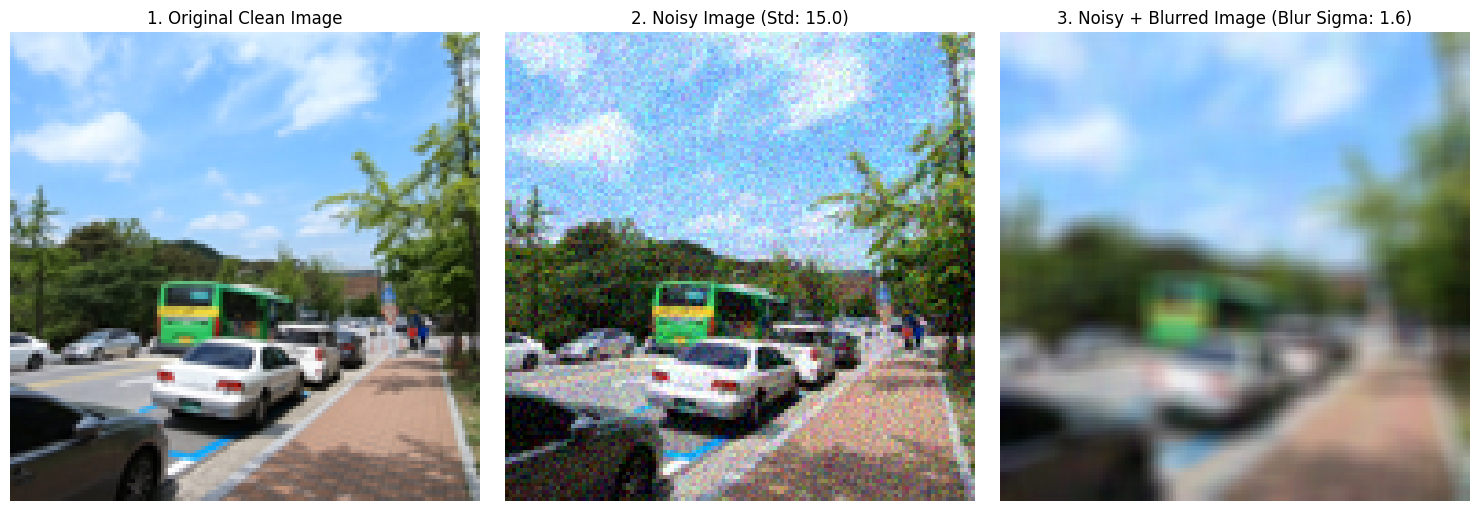

In [ ]:


#  Ensure best_cfg is available 
if 'best_cfg' not in globals():
    if 'tuning_results' in globals():
        best = min(tuning_results, key=lambda r: r["avg_val_loss"])
        best_cfg = best["config"]
        print("Best configuration loaded from tuning_results:")
    else:
        # Fallback to a reasonable default if tuning_results is not available
        best_cfg = {'learning_rate': 3e-4, 'batch_size': 8, 'num_epochs': 8, 'noise_std': 15.0, 'blur_sigma': 1.6, 'base_channels': 128}
        print("Default best_cfg used for visualization (tuning_results not found):")
    print(best_cfg)

# Ensure hr_path and hr_subdirs are available 
if 'hr_path' not in globals():
    hr_path = '/content/data/hr'
if 'hr_subdirs' not in globals():
    if os.path.exists(hr_path):
        hr_subdirs = sorted([d for d in os.listdir(hr_path) if os.path.isdir(os.path.join(hr_path, d))])
    else:
        hr_subdirs = [] 

if not hr_subdirs:
    raise ValueError("No HR subdirectories found in hr_path. Cannot create dataset.")

# Create a dataset instance with best_cfg parameters
sample_dataset_full_degradation = REDDenoiseDataset(
    hr_root=hr_path,
    hr_subdirs=hr_subdirs[:1], 
    image_size=128,
    noise_std=best_cfg["noise_std"],
    blur_sigma=best_cfg["blur_sigma"],
)

# Retrieve a sample (noisy+blurred, clean) pair from the dataset 
noisy_blurred_tensor, clean_tensor = sample_dataset_full_degradation[0]

# Create a 'noisy only' version for comparison ---
# separate dataset instance for this if blur_sigma > 0
if best_cfg["blur_sigma"] > 0:
    sample_dataset_noisy_only = REDDenoiseDataset(
        hr_root=hr_path,
        hr_subdirs=hr_subdirs[:1], 
        image_size=128,
        noise_std=best_cfg["noise_std"],
        blur_sigma=0.0, 
    )
    noisy_tensor, _ = sample_dataset_noisy_only[0]
else:
    
    noisy_tensor = noisy_blurred_tensor

print(f"\nVisualizing first image from {hr_path}/{hr_subdirs[0]} with best config degradations:")

clean_tensor_display = torch.clamp(clean_tensor, 0.0, 1.0)
noisy_tensor_display = torch.clamp(noisy_tensor, 0.0, 1.0)
noisy_blurred_tensor_display = torch.clamp(noisy_blurred_tensor, 0.0, 1.0)

# Convert tensors to numpy for plotting 
clean_np = (clean_tensor_display.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
noisy_np = (noisy_tensor_display.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
noisy_blurred_np = (noisy_blurred_tensor_display.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

# Visualize 
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(clean_np)
plt.title('1. Original Clean Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_np)
plt.title(f'2. Noisy Image (Std: {best_cfg["noise_std"]:.1f})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(noisy_blurred_np)
plt.title(f'3. Noisy + Blurred Image (Blur Sigma: {best_cfg["blur_sigma"]:.1f})')
plt.axis('off')

plt.tight_layout()
plt.show()

### Hyperparameter Tuning Setup
This code block initializes and runs a hyperparameter tuning process for the U-Net denoising model. It iterates through a predefined list of hyperparameter_combinations, creating a REDDenoiseDataset for each configuration, and then splitting it into training and validation sets. It sets up DataLoader instances for both, preparing the data for model training and evaluation.

In [ ]:
tuning_results = []

num_subdirs_for_tuning = min(10, len(hr_subdirs))
tuning_subdirs = hr_subdirs[:num_subdirs_for_tuning]
print("Using subdirs for tuning:", tuning_subdirs)

for idx, cfg in enumerate(hyperparameter_combinations, 1):
    print("\nRunning configuration", idx, "of", len(hyperparameter_combinations))
    print(cfg)

    dataset_tune = REDDenoiseDataset(
        hr_root=hr_path,
        hr_subdirs=tuning_subdirs,
        image_size=128,
        noise_std=cfg["noise_std"],
        blur_sigma=cfg["blur_sigma"],
    )

    train_size = int(0.8 * len(dataset_tune))
    val_size = len(dataset_tune) - train_size
    train_dataset, val_dataset = random_split(dataset_tune, [train_size, val_size])

    train_loader = DataLoader(train_dataset,
                              batch_size=cfg["batch_size"],
                              shuffle=True,
                              num_workers=2)
    val_loader = DataLoader(val_dataset,
                            batch_size=cfg["batch_size"],
                            shuffle=False,
                            num_workers=2)

    model = UNet(
        n_channels=3,
        n_classes=3,
        base_channels=cfg["base_channels"],
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    criterion = nn.L1Loss()

    val_losses = []

    for epoch in range(cfg["num_epochs"]):
        model.train()
        running_loss = 0.0
        for noisy, clean in tqdm(train_loader,
                                 desc=f"Config {idx} Epoch {epoch+1}/{cfg['num_epochs']} Train"):
            noisy = noisy.to(device)
            clean = clean.to(device)

            optimizer.zero_grad()
            out = model(noisy)
            loss = criterion(out, clean)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * noisy.size(0)

        train_loss = running_loss / len(train_dataset)

        model.eval()
        val_running = 0.0
        psnrs = []
        ssims = []
        with torch.no_grad():
            for noisy_v, clean_v in tqdm(val_loader,
                                         desc=f"Config {idx} Epoch {epoch+1}/{cfg['num_epochs']} Val"):
                noisy_v = noisy_v.to(device)
                clean_v = clean_v.to(device)
                out_v = model(noisy_v)

                loss_v = criterion(out_v, clean_v)
                val_running += loss_v.item() * noisy_v.size(0)

                for j in range(noisy_v.size(0)):
                    orig_np = (clean_v[j].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
                    den_np = (out_v[j].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

                    psnr = peak_signal_noise_ratio(orig_np, den_np, data_range=255)
                    ssim = structural_similarity(orig_np, den_np,
                                                 data_range=255,
                                                 channel_axis=-1)
                    psnrs.append(psnr)
                    ssims.append(ssim)

        val_loss = val_running / len(val_dataset)
        val_losses.append(val_loss)
        print("Epoch", epoch + 1,
              "train loss", round(train_loss, 4),
              "val loss", round(val_loss, 4),
              "PSNR", np.mean(psnrs).round(2),
              "SSIM", np.mean(ssims).round(3))

    result = {
        "config": cfg,
        "avg_val_loss": val_losses[-1],
        "avg_val_psnr": float(np.mean(psnrs)),
        "avg_val_ssim": float(np.mean(ssims)),
    }
    tuning_results.append(result)
    print("Summary for config", idx, result)

print("\nAll tuning results:")
for r in tuning_results:
    print(r)


Using subdirs for tuning: ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009']

Running configuration 1 of 3
{'learning_rate': 0.001, 'batch_size': 16, 'num_epochs': 6, 'noise_std': 8.0, 'blur_sigma': 1.0, 'base_channels': 64}


Config 1 Epoch 1/6 Val: 100%|██████████| 13/13 [00:03<00:00,  3.35it/s]


Epoch 1 train loss 0.1073 val loss 0.0655 PSNR 20.89 SSIM 0.674


Config 1 Epoch 2/6 Val: 100%|██████████| 13/13 [00:03<00:00,  3.71it/s]


Epoch 2 train loss 0.0557 val loss 0.0515 PSNR 17.37 SSIM 0.692


...

Epoch 6 train loss 0.0464 val loss 0.0428 PSNR 17.57 SSIM 0.745


Config 3 Epoch 7/8 Val: 100%|██████████| 25/25 [00:03<00:00,  6.87it/s]


Epoch 7 train loss 0.0434 val loss 0.0431 PSNR 23.36 SSIM 0.793


Config 3 Epoch 8/8 Val: 100%|██████████| 25/25 [00:03<00:00,  6.77it/s]

Epoch 8 train loss 0.0434 val loss 0.0398 PSNR 21.5 SSIM 0.781
Summary for config 3 {'config': {'learning_rate': 0.0003, 'batch_size': 8, 'num_epochs': 8, 'noise_std': 15.0, 'blur_sigma': 1.6, 'base_channels': 128}, 'avg_val_loss': 0.03978288486599922, 'avg_val_psnr': 21.50180034583908, 'avg_val_ssim': 0.7809045334988156}

All tuning results:
{'config': {'learning_rate': 0.001, 'batch_size': 16, 'num_epochs': 6, 'noise_std': 8.0, 'blur_sigma': 1.0, 'base_channels': 64}, 'avg_val_loss': 0.04734626203775406, 'avg_val_psnr': 14.654753169965975, 'avg_val_ssim': 0.7424176258163029}
{'config': {'learning_rate': 0.0005, 'batch_size': 16, 'num_epochs': 6, 'noise_std': 12.0, 'blur_sigma': 1.3, 'base_channels': 96}, 'avg_val_loss': 0.05312476664781571, 'avg_val_psnr': 16.54597177341912, 'avg_val_ssim': 0.6599007954817}
{'config': {'learning_rate': 0.0003, 'batch_size': 8, 'num_epochs': 8, 'noise_std': 15.0, 'blur_sigma': 1.6, 'base_channels': 128}, 'avg_val_loss': 0.03978288486599922, 'avg_val_p

pick best config and train final model

### Pick Best Config and Train Final Model
This code block first identifies the best hyperparameter configuration from the tuning_results based on the lowest validation loss. It then uses this best_cfg to:

1.  Initialize a REDDenoiseDataset using the full dataset with the chosen noise and blur parameters.
2.  Split the data into training and validation sets and create DataLoader instances.
3.  Instantiate a new UNet model with the best base_channels.
4.  Train the final model_final for a specified number of final_epochs (55 in this case) using the selected learning rate and batch size. During training, it evaluates performance using validation loss, PSNR, and SSIM.
5.  Finally, it saves the trained model's state dictionary to /content/unet_red_best.pth.

In [ ]:
best = min(tuning_results, key=lambda r: r["avg_val_loss"])
best_cfg = best["config"]
print("Best configuration based on val loss:")
print(best_cfg)
print(best)

# We pick the config that gave the lowest validation loss during tuning.
# Now we retrain on the full dataset using that configuration 


final_dataset = REDDenoiseDataset(
    hr_root=hr_path,
    hr_subdirs=hr_subdirs,
    image_size=128,
    noise_std=best_cfg["noise_std"],
    blur_sigma=best_cfg["blur_sigma"],
)

train_size = int(0.9 * len(final_dataset))
val_size = len(final_dataset) - train_size
train_dataset_full, val_dataset_full = random_split(final_dataset, [train_size, val_size])

train_loader_full = DataLoader(train_dataset_full,
                               batch_size=best_cfg["batch_size"],
                               shuffle=True,
                               num_workers=2)
val_loader_full = DataLoader(val_dataset_full,
                             batch_size=best_cfg["batch_size"],
                             shuffle=False,
                             num_workers=2)

model_final = UNet(
    n_channels=3,
    n_classes=3,
    base_channels=best_cfg["base_channels"],
).to(device)

optimizer_final = optim.Adam(model_final.parameters(), lr=best_cfg["learning_rate"])
criterion_final = nn.L1Loss()

final_epochs = 55
print("Starting final training for", final_epochs, "epochs")

for epoch in range(final_epochs):
    model_final.train()
    running_loss = 0.0
    for noisy, clean in tqdm(train_loader_full,
                             desc=f"Final Epoch {epoch+1}/{final_epochs} Train"):
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer_final.zero_grad()
        out = model_final(noisy)
        loss = criterion_final(out, clean)
        loss.backward()
        optimizer_final.step()

        running_loss += loss.item() * noisy.size(0)

    train_loss = running_loss / len(train_dataset_full)

    model_final.eval()
    val_running = 0.0
    psnrs = []
    ssims = []
    with torch.no_grad():
        for noisy_v, clean_v in tqdm(val_loader_full,
                                     desc=f"Final Epoch {epoch+1}/{final_epochs} Val"):
            noisy_v = noisy_v.to(device)
            clean_v = clean_v.to(device)
            out_v = model_final(noisy_v)

            loss_v = criterion_final(out_v, clean_v)
            val_running += loss_v.item() * noisy_v.size(0)

            for j in range(noisy_v.size(0)):
                orig_np = (clean_v[j].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
                den_np = (out_v[j].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
                psnr = peak_signal_noise_ratio(orig_np, den_np, data_range=255)
                ssim = structural_similarity(orig_np, den_np,
                                             data_range=255,
                                             channel_axis=-1)
                psnrs.append(psnr)
                ssims.append(ssim)

    val_loss = val_running / len(val_dataset_full)
    # Quick, human-readable progress line — useful while monitoring training:
    print("Final epoch", epoch + 1,
          "train loss", round(train_loss, 4),
          "val loss", round(val_loss, 4),
          "PSNR", np.mean(psnrs).round(2),
          "SSIM", np.mean(ssims).round(3))

# Save the trained model weights — you can download this file from the Colab session.
torch.save(model_final.state_dict(), "/content/unet_red_best.pth")
print("Saved model to /content/unet_red_best.pth")


Best configuration based on val loss:
{'learning_rate': 0.0003, 'batch_size': 8, 'num_epochs': 8, 'noise_std': 15.0, 'blur_sigma': 1.6, 'base_channels': 128}
{'config': {'learning_rate': 0.0003, 'batch_size': 8, 'num_epochs': 8, 'noise_std': 15.0, 'blur_sigma': 1.6, 'base_channels': 128}, 'avg_val_loss': 0.03978288486599922, 'avg_val_psnr': 21.50180034583908, 'avg_val_ssim': 0.7809045334988156}
Starting final training for 55 epochs


Final Epoch 1/55 Val: 100%|██████████| 300/300 [00:42<00:00,  7.03it/s]


Final epoch 1 train loss 0.0508 val loss 0.0373 PSNR 24.66 SSIM 0.813


Final Epoch 2/55 Val: 100%|██████████| 300/300 [00:42<00:00,  7.01it/s]


Final epoch 2 train loss 0.0399 val loss 0.0355 PSNR 22.86 SSIM 0.814


...

Final epoch 53 train loss 0.0206 val loss 0.0211 PSNR 28.08 SSIM 0.918


Final Epoch 54/55 Val: 100%|██████████| 300/300 [00:41<00:00,  7.20it/s]


Final epoch 54 train loss 0.0206 val loss 0.0212 PSNR 29.02 SSIM 0.92


Final Epoch 55/55 Val: 100%|██████████| 300/300 [00:42<00:00,  7.13it/s]


Final epoch 55 train loss 0.0206 val loss 0.021 PSNR 29.13 SSIM 0.92
Saved model to /content/unet_red_best.pth


### Load the Trained Model
 initializes a UNet model with the base_channels from the best configuration and loads the previously saved weights from /content/unet_red_best.pth. It then sets the model to evaluation mode (model.eval()) in preparation for inference, ensuring it is ready to denoise images.

In [ ]:
# Cell: Load the trained model

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model = UNet(base_channels=128).to(device)  # Use base_channels=128 from your best config
final_model.load_state_dict(torch.load('/content/unet_red_best.pth'))
final_model.eval()

print("✓ Model loaded successfully!")

✓ Model loaded successfully!


In [ ]:


# Path to your trained model
model_path = '/content/unet_red_best.pth'

try:
    files.download(model_path)
    print(f"Successfully initiated download for {model_path}")
except Exception as e:
    print(f"Error downloading model: {e}")
    print("Please ensure the file exists and try again.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully initiated download for /content/unet_red_best.pth


In [ ]:
# validation dataset for testing
test_dataset = val_dataset_full

print(f"✓ Created test dataset with {len(test_dataset)} samples (using val_dataset_full)")

✓ Created test dataset with 2400 samples (using val_dataset_full)


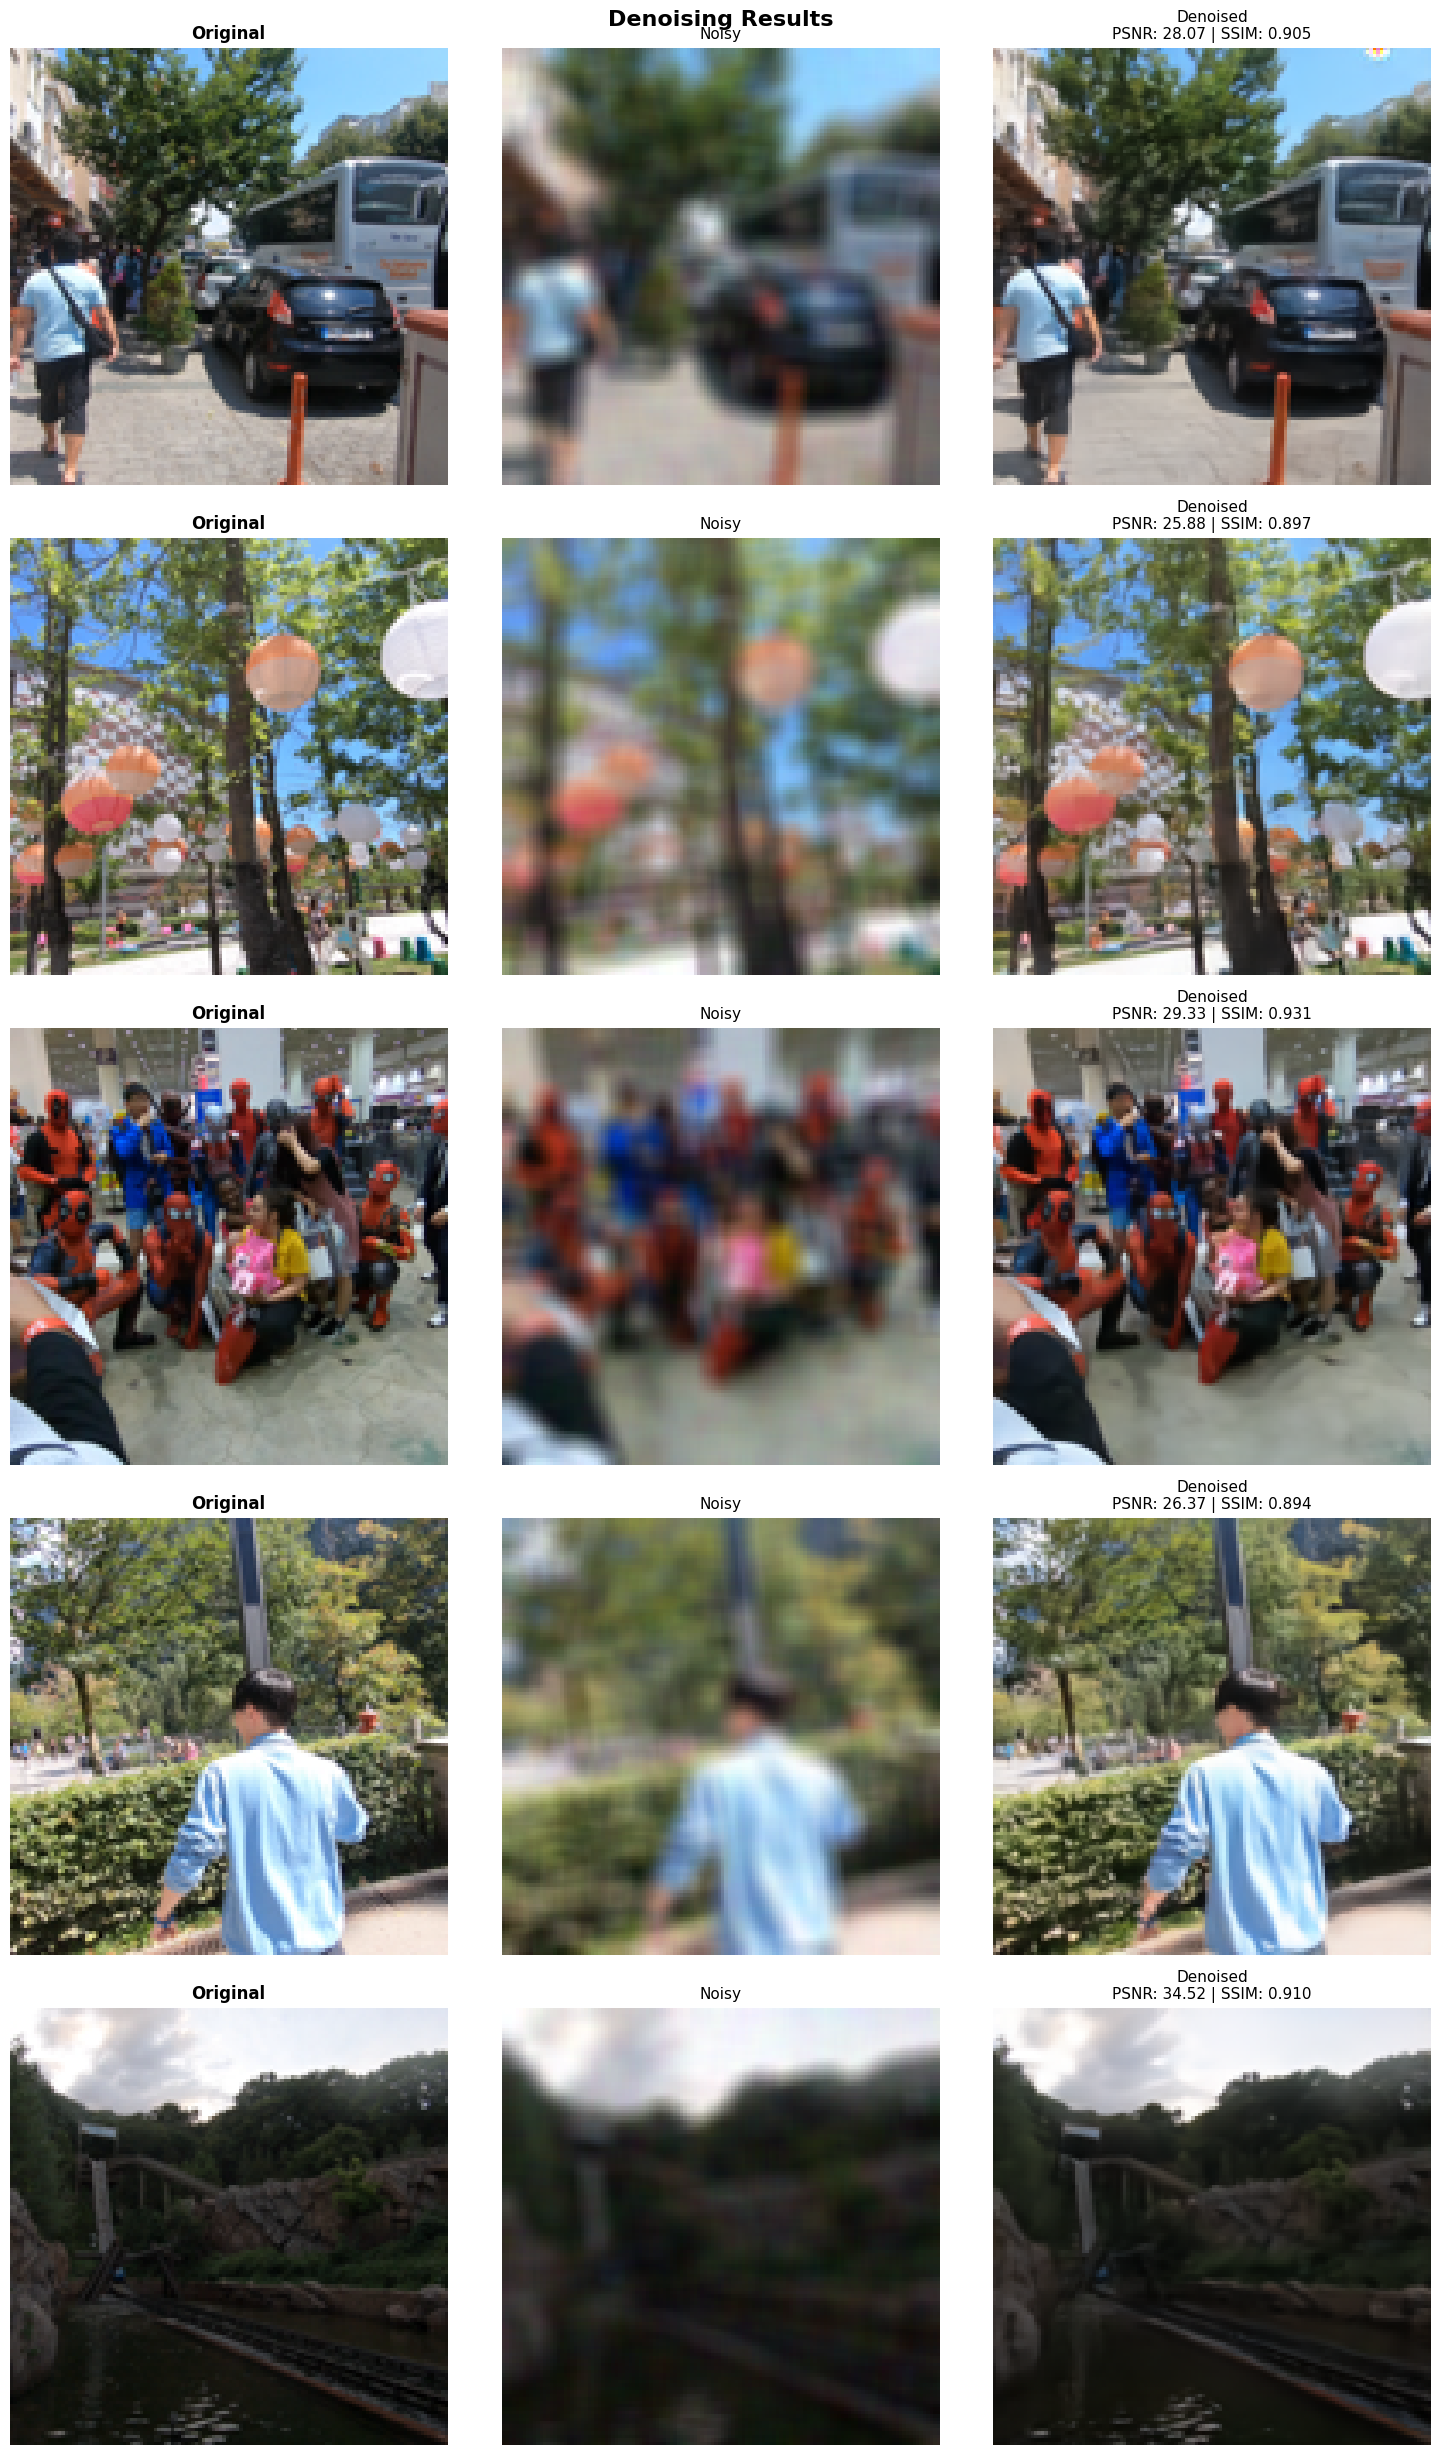

In [ ]:
 #visualization of denoising results


def visualize_results(model, dataset, device, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for idx in range(num_samples):
            noisy, clean = dataset[idx]
            noisy_batch = noisy.unsqueeze(0).to(device)
            denoised = model(noisy_batch).squeeze(0).cpu()

            # Convert to numpy
            noisy_np = (noisy.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            clean_np = (clean.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            denoised_np = np.clip((denoised.permute(1, 2, 0).numpy() * 255), 0, 255).astype(np.uint8)

            # Calculate metrics
            psnr = peak_signal_noise_ratio(clean_np, denoised_np, data_range=255)
            ssim = structural_similarity(clean_np, denoised_np, channel_axis=2, data_range=255)

            # Display
            axes[idx, 0].imshow(clean_np)
            axes[idx, 0].set_title('Original', fontsize=12, fontweight='bold')
            axes[idx, 0].axis('off')

            axes[idx, 1].imshow(noisy_np)
            axes[idx, 1].set_title(f'Noisy', fontsize=11)
            axes[idx, 1].axis('off')

            axes[idx, 2].imshow(denoised_np)
            axes[idx, 2].set_title(f'Denoised\nPSNR: {psnr:.2f} | SSIM: {ssim:.3f}', fontsize=11)
            axes[idx, 2].axis('off')

    plt.suptitle('Denoising Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_results(final_model, test_dataset, device, num_samples=5)

In [2]:
# Cell: Create videos and download to PC


def save_and_download_videos(model, dataset, device, num_frames=50, fps=10):
    """Create and download original, noisy, and denoised videos"""

    print("\n" + "="*60)
    print("CREATING VIDEOS")
    print("="*60)

    # Create output directories
    output_dir = '/content/video_frames'
    os.makedirs(os.path.join(output_dir, 'original'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'noisy'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'denoised'), exist_ok=True)

    # Save frames
    print(f"\n1. Saving {num_frames} frames...")
    model.eval()
    with torch.no_grad():
        for idx in range(min(num_frames, len(dataset))):
            noisy, clean = dataset[idx]
            noisy_batch = noisy.unsqueeze(0).to(device)
            denoised = model(noisy_batch).squeeze(0).cpu()

            # Convert to numpy BGR for OpenCV
            noisy_np = (noisy.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            clean_np = (clean.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            denoised_np = np.clip((denoised.permute(1, 2, 0).numpy() * 255), 0, 255).astype(np.uint8)

            clean_bgr = cv2.cvtColor(clean_np, cv2.COLOR_RGB2BGR)
            noisy_bgr = cv2.cvtColor(noisy_np, cv2.COLOR_RGB2BGR)
            denoised_bgr = cv2.cvtColor(denoised_np, cv2.COLOR_RGB2BGR)

            # Save
            cv2.imwrite(os.path.join(output_dir, 'original', f'frame_{idx:04d}.png'), clean_bgr)
            cv2.imwrite(os.path.join(output_dir, 'noisy', f'frame_{idx:04d}.png'), noisy_bgr)
            cv2.imwrite(os.path.join(output_dir, 'denoised', f'frame_{idx:04d}.png'), denoised_bgr)

            if (idx + 1) % 10 == 0:
                print(f"   Saved {idx + 1}/{num_frames} frames")

    print("   ✓ All frames saved!")

    # Create videos
    print("\n2. Creating videos...")

    def create_video(frame_dir, output_path, label):
        frames = sorted([f for f in os.listdir(frame_dir) if f.endswith('.png')])
        first = cv2.imread(os.path.join(frame_dir, frames[0]))
        h, w = first.shape[:2]

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

        for frame_file in frames:
            frame = cv2.imread(os.path.join(frame_dir, frame_file))
            cv2.putText(frame, label, (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)
            out.write(frame)

        out.release()
        print(f"   ✓ Created {output_path}")
        return output_path

    original_vid = create_video(os.path.join(output_dir, 'original'), '/content/original.mp4', 'ORIGINAL')
    noisy_vid = create_video(os.path.join(output_dir, 'noisy'), '/content/noisy.mp4', 'NOISY')
    denoised_vid = create_video(os.path.join(output_dir, 'denoised'), '/content/denoised.mp4', 'DENOISED')

    # Create comparison video
    print("\n3. Creating comparison video...")
    frames = sorted([f for f in os.listdir(os.path.join(output_dir, 'original')) if f.endswith('.png')])
    first = cv2.imread(os.path.join(output_dir, 'original', frames[0]))
    h, w = first.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    comparison_vid = '/content/comparison.mp4'
    out = cv2.VideoWriter(comparison_vid, fourcc, fps, (w*3, h))

    for frame_file in frames:
        orig = cv2.imread(os.path.join(output_dir, 'original', frame_file))
        noisy = cv2.imread(os.path.join(output_dir, 'noisy', frame_file))
        denoised = cv2.imread(os.path.join(output_dir, 'denoised', frame_file))

        cv2.putText(orig, 'ORIGINAL', (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
        cv2.putText(noisy, 'NOISY', (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2)
        cv2.putText(denoised, 'DENOISED', (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)

        combined = np.hstack([orig, noisy, denoised])
        out.write(combined)

    out.release()
    print(f"   ✓ Created {comparison_vid}")

    # Download all videos
    print("\n" + "="*60)
    print("DOWNLOADING VIDEOS")
    print("="*60)

    print("\n Downloading videos to your PC...")
    files.download('/content/original.mp4')
    files.download('/content/noisy.mp4')
    files.download('/content/denoised.mp4')
    files.download('/content/comparison.mp4')

    print("\n✓ ALL VIDEOS DOWNLOADED!")
    print("  1. original.mp4 - Clean original frames")
    print("  2. noisy.mp4 - Noisy input")
    print("  3. denoised.mp4 - AI denoised output ")
    print("  4. comparison.mp4 - Side-by-side view")

# Run it!
save_and_download_videos(final_model, test_dataset, device, num_frames=50, fps=10)

NameError: name 'final_model' is not defined